# Kalibrasi dan Runtime Hybrid Tanpa LLM
Notebook ini menjalankan pipeline hybrid tanpa LLM secara end-to-end melalui CLI/service proyek. Progress tahap utama ditampilkan dengan `tqdm`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

from IPython.display import display
import polars as pl
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.artifact_service import ArtifactService

artifact_service = ArtifactService()
PROJECT_ROOT


e:\Software\laragon\bin\python\python-3.13.11-amd64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('E:/School/tugas-akhir/project')

## 1. Konfigurasi Eksekusi

In [2]:
EXPERIMENT_ID = "hybrid_indobert_socal_manual"
EXPERIMENT_DIR = Path(config.EXPERIMENT_CONFIG["artifact_root"]) / EXPERIMENT_ID
MODEL_DIR = EXPERIMENT_DIR / "model"
RUNTIME_DIR = EXPERIMENT_DIR / "runtime"

RUN_BUILD_TRAINING_DATASET = True
RUN_CREATE_FIXED_SPLIT = True
RUN_TRAIN_MODEL = not (MODEL_DIR / "config.json").exists()
RUN_CALIBRATE = True
RUN_RUNTIME_WITHOUT_LLM = True

print("Experiment dir:", EXPERIMENT_DIR)
print("Model exists:", (MODEL_DIR / "config.json").exists())
print("RUN_TRAIN_MODEL:", RUN_TRAIN_MODEL)


Experiment dir: E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual
Model exists: True
RUN_TRAIN_MODEL: False


## 2. Jalankan Pipeline End-to-End

In [3]:
stages = [
    (
        "build-training-dataset",
        RUN_BUILD_TRAINING_DATASET,
        [sys.executable, "main.py", "build-training-dataset"],
    ),
    (
        "create-fixed-group-split",
        RUN_CREATE_FIXED_SPLIT,
        [sys.executable, "main.py", "create-fixed-group-split"],
    ),
    (
        "train-indobert",
        RUN_TRAIN_MODEL,
        [sys.executable, "main.py", "train-indobert", "--experiment-id", EXPERIMENT_ID],
    ),
    (
        "calibrate-indobert",
        RUN_CALIBRATE,
        [sys.executable, "main.py", "calibrate-indobert", "--experiment-dir", str(EXPERIMENT_DIR)],
    ),
    (
        "run-without-llm",
        RUN_RUNTIME_WITHOUT_LLM,
        [
            sys.executable,
            "main.py",
            "run-without-llm",
            "--model-dir",
            str(MODEL_DIR),
            "--calibration-artifact",
            str(EXPERIMENT_DIR / "calibration_artifact.json"),
            "--fusion-policy",
            str(EXPERIMENT_DIR / "fusion_policy.json"),
            "--output-dir",
            str(RUNTIME_DIR),
        ],
    ),
]

completed_stages = []
for stage_name, enabled, command in tqdm(stages, desc="Pipeline tanpa LLM", unit="stage"):
    if not enabled:
        tqdm.write(f"SKIP {stage_name}")
        completed_stages.append({"stage": stage_name, "status": "skipped"})
        continue

    tqdm.write(f"RUN  {stage_name}")
    tqdm.write(" ".join(str(part) for part in command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    completed_stages.append({"stage": stage_name, "status": "done"})

completed_stages


Pipeline tanpa LLM:   0%|          | 0/5 [00:00<?, ?stage/s]

RUN  build-training-dataset
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py build-training-dataset


Pipeline tanpa LLM:  20%|██        | 1/5 [00:00<00:01,  2.47stage/s]

RUN  create-fixed-group-split
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py create-fixed-group-split


Pipeline tanpa LLM:  40%|████      | 2/5 [00:02<00:04,  1.63s/stage]

SKIP train-indobert
RUN  calibrate-indobert
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py calibrate-indobert --experiment-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual


Pipeline tanpa LLM:  80%|████████  | 4/5 [00:15<00:04,  4.52s/stage]

RUN  run-without-llm
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py run-without-llm --model-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\model --calibration-artifact E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\calibration_artifact.json --fusion-policy E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\fusion_policy.json --output-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\runtime


Pipeline tanpa LLM: 100%|██████████| 5/5 [03:36<00:00, 43.32s/stage]


[{'stage': 'build-training-dataset', 'status': 'done'},
 {'stage': 'create-fixed-group-split', 'status': 'done'},
 {'stage': 'train-indobert', 'status': 'skipped'},
 {'stage': 'calibrate-indobert', 'status': 'done'},
 {'stage': 'run-without-llm', 'status': 'done'}]

## 3. Cek Artifact Utama

In [4]:
artifact_paths = {
    "training_dataset": config.TRAINING_DATASET_PATH,
    "training_dataset_with_split": config.TRAINING_DATASET_WITH_SPLIT_PATH,
    "training_manifest": config.ARTIFACTS / "training_dataset_manifest.json",
    "split_manifest": config.FIXED_SPLIT_MANIFEST_PATH,
    "model_dir": MODEL_DIR,
    "model_manifest": EXPERIMENT_DIR / "model_manifest.json",
    "calibration_artifact": EXPERIMENT_DIR / "calibration_artifact.json",
    "fusion_policy": EXPERIMENT_DIR / "fusion_policy.json",
    "metrics": EXPERIMENT_DIR / "metrics.json",
    "runtime_predictions_parquet": RUNTIME_DIR / "scenario_without_llm_predictions.parquet",
    "runtime_predictions_csv": RUNTIME_DIR / "scenario_without_llm_predictions.csv",
    "runtime_summary": RUNTIME_DIR / "scenario_without_llm_summary.json",
}

artifact_df = pl.DataFrame(
    [
        {"artifact": name, "path": str(path), "exists": Path(path).exists()}
        for name, path in artifact_paths.items()
    ]
)
display(artifact_df)


artifact,path,exists
str,str,bool
"""training_dataset""","""E:\School\tugas-akhir\project\…",true
"""training_dataset_with_split""","""E:\School\tugas-akhir\project\…",true
"""training_manifest""","""E:\School\tugas-akhir\project\…",true
"""split_manifest""","""E:\School\tugas-akhir\project\…",true
"""model_dir""","""E:\School\tugas-akhir\project\…",true
…,…,…
"""fusion_policy""","""E:\School\tugas-akhir\project\…",true
"""metrics""","""E:\School\tugas-akhir\project\…",true
"""runtime_predictions_parquet""","""E:\School\tugas-akhir\project\…",true


## 4. Manifest, Calibration, Policy, dan Metrics

In [5]:
def load_json_if_exists(path: Path):
    if not path.exists():
        print(f"Belum ada: {path}")
        return None
    return json.loads(path.read_text(encoding=config.ENCODING))

training_manifest = load_json_if_exists(config.ARTIFACTS / "training_dataset_manifest.json")
split_manifest = load_json_if_exists(config.FIXED_SPLIT_MANIFEST_PATH)
calibration_artifact = load_json_if_exists(EXPERIMENT_DIR / "calibration_artifact.json")
fusion_policy = load_json_if_exists(EXPERIMENT_DIR / "fusion_policy.json")
metrics = load_json_if_exists(EXPERIMENT_DIR / "metrics.json")
runtime_summary = load_json_if_exists(RUNTIME_DIR / "scenario_without_llm_summary.json")

for title, payload in [
    ("training_manifest", training_manifest),
    ("split_manifest", split_manifest),
    ("calibration_artifact", calibration_artifact),
    ("fusion_policy", fusion_policy),
    ("metrics", metrics),
    ("runtime_summary", runtime_summary),
]:
    if payload is not None:
        print("\n===", title, "===")
        display(payload)



=== training_manifest ===


{'row_count': 281,
 'label_distribution': {'positif': 138, 'negatif': 82, 'netral': 61},
 'metadata_recovery_distribution': {'matched_by_base_text_id': 281},
 'group_count': 74,
 'metadata_paths': ['E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v1_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v2_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v3_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v4_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v5_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v6_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v7_candidate_labeling_dataset.csv',
  'E:\\School\\tugas-akhir\\project\\outputs\\datasets\\v8_candidate_labeling_dataset.csv'],
 'gates': {'total_is_281': True,
  'positif_is_138': True,
  'negat


=== split_manifest ===


{'split_config': {'n_splits': 6,
  'test_fold': 0,
  'calibration_fold': 1,
  'train_folds': [2, 3, 4, 5],
  'random_state': 42},
 'row_count': 281,
 'group_count': 74,
 'split_counts': {'train': 185, 'calibration': 49, 'test': 47},
 'per_split_label_distribution': {'train': {'netral': 40,
   'positif': 90,
   'negatif': 55},
  'calibration': {'positif': 25, 'negatif': 14, 'netral': 10},
  'test': {'netral': 11, 'positif': 23, 'negatif': 13}},
 'overlaps': {'train_calibration': [],
  'train_test': [],
  'calibration_test': []},
 'gates': {'all_rows_have_split': True,
  'row_count_is_281': True,
  'no_group_overlap': True,
  'calibration_not_training': True,
  'test_not_training': True},
 'all_gates_passed': True}


=== calibration_artifact ===


...

{'high_confidence_threshold': 0.85,
 'low_confidence_threshold': 0.45,
 'rule_confidence_threshold': 0.35,
 'uncertainty_review_threshold': 0.5,
 'uncertainty_weights': {'wc': 0.5, 'wm': 0.3, 'wd': 0.2},
 'selection_metric': {'balanced_accuracy': 0.8248,
  'macro_f1': 0.8494,
  'override_count': 0},
 'candidate_count': 1024}


=== metrics ===


{'calibration': {'indobert': {'total': 49,
   'accuracy': 0.8571,
   'balanced_accuracy': 0.8248,
   'macro_f1': 0.8494,
   'weighted_f1': 0.8552,
   'per_label': {'negatif': {'precision': 1.0,
     'recall': 0.7143,
     'f1': 0.8333,
     'support': 14},
    'netral': {'precision': 0.8889,
     'recall': 0.8,
     'f1': 0.8421,
     'support': 10},
    'positif': {'precision': 0.8,
     'recall': 0.96,
     'f1': 0.8727,
     'support': 25}},
   'confusion_matrix': {'negatif': {'negatif': 10, 'netral': 0, 'positif': 4},
    'netral': {'negatif': 0, 'netral': 8, 'positif': 2},
    'positif': {'negatif': 0, 'netral': 1, 'positif': 24}},
   'actual_distribution': {'positif': 25, 'negatif': 14, 'netral': 10},
   'predicted_distribution': {'netral': 9, 'positif': 30, 'negatif': 10},
   'nll': 0.433616,
   'ece': 0.126665,
   'multiclass_brier_score': 0.234044},
  'rule_based': {'total': 49,
   'accuracy': 0.2449,
   'balanced_accuracy': 0.36,
   'macro_f1': 0.1667,
   'weighted_f1': 0.145


=== runtime_summary ===


{'input_path': 'E:\\School\\tugas-akhir\\project\\datasets\\raw_candidate_schema.csv',
 'model_dir': 'E:\\School\\tugas-akhir\\project\\outputs\\artifacts\\experiments\\hybrid_indobert_socal_manual\\model',
 'calibration_artifact_path': 'E:\\School\\tugas-akhir\\project\\outputs\\artifacts\\experiments\\hybrid_indobert_socal_manual\\calibration_artifact.json',
 'fusion_policy_path': 'E:\\School\\tugas-akhir\\project\\outputs\\artifacts\\experiments\\hybrid_indobert_socal_manual\\fusion_policy.json',
 'input_rows': 1080,
 'deduplicated_rows': 1080,
 'output_rows': 1080,
 'final_sentiment_distribution': {'netral': 829,
  'positif': 141,
  'negatif': 110},
 'needs_review_count': 177,
 'fusion_action_distribution': {'bert_rule_invalid': 626,
  'bert_default': 260,
  'agreement': 107,
  'rule_override': 7,
  'bert_high_confidence': 80},
 'invalid_labels': [],
 'gates': {'all_runtime_rows_have_final_sentiment': True,
  'all_labels_valid': True,
  'every_decision_has_fusion_reason': True,
  '

## 5. Preview Output Runtime

In [6]:
predictions_path = RUNTIME_DIR / "scenario_without_llm_predictions.parquet"
if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)
    display(predictions_df.head(20))

    if {"final_sentiment", "needs_review"}.issubset(set(predictions_df.columns)):
        display(
            predictions_df
            .group_by(["final_sentiment", "needs_review"])
            .len()
            .sort(["final_sentiment", "needs_review"])
        )
else:
    print("Runtime predictions belum tersedia:", predictions_path)


text_id,original_text,processed_text,bert_label,bert_prob_negatif,bert_prob_netral,bert_prob_positif,bert_confidence,bert_margin,bert_entropy,rule_contract_version,rule_resource_version,rule_label,rule_score,rule_confidence,rule_status,rule_positive_score,rule_negative_score,rule_positive_count,rule_negative_count,rule_hits,rule_neutral_hits,rule_phrase_hits,rule_word_hits,rule_modifier_hits,rule_evidence,rule_explanation,cross_method_conflict,confidence_uncertainty,margin_uncertainty,routing_uncertainty_score,fusion_action,fusion_reason,final_sentiment,needs_review,source_url,source_type,…,subjectivity_type,speaker_type,public_opinion_scope,corpus_role,aspect,sentiment_label,label_status,source_id,dataset_tier,inclusion_status,verification_status,evidence_support_score,parent_text_id,decision_note,raw_source_file,raw_domain,content_status,query_group,query,raw_title,raw_text_length,location_source,location_match,is_specific_location,blacklist_status,blacklist_reason_codes,normalized_source_url,blacklist_is_excluded,bert_label_id,bert_logit_negatif,bert_logit_netral,bert_logit_positif,bert_temperature,normalized_entropy,uncertainty_weight_wc,uncertainty_weight_wm,uncertainty_weight_wd
str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,str,f64,f64,i64,i64,str,str,str,str,str,str,str,bool,f64,f64,f64,str,str,str,bool,str,str,…,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,i64,str,str,bool,str,str,str,bool,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""RAW-0003""","""OIS POWER on Instagram: ""#PLTS…","""ois power on instagram pembang…","""netral""",0.081203,0.870482,0.048315,0.870482,0.78928,0.428744,"""2.0.0""","""socal_metadata=1.0.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"""""","""""","""""","""""","""""","""{""method"": ""SO-CAL-inspired"", …","""Tidak ada rule sentimen yang d…",false,0.129518,0.21072,0.127975,"""bert_rule_invalid""","""Rule weak/unknown/tanpa eviden…","""netral""",false,"""https://www.instagram.com/reel…","""social_media""",…,"""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""general_shs""","""""","""unlabeled""","""RAW-SRC-0003""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""",0.9,"""""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""OIS POWER | #PLTS #PanelSurya …",371,"""query""","""sambas""",true,"""clear""","""[]""","""https://instagram.com/reel/DY0…",false,1,-1.371848,3.415801,-2.419748,2.018316,0.428744,0.5,0.3,0.2
"""RAW-0004""","""TEKNIK LISTRIK on Instagram: ""…","""teknik listrik on instagram pa…","""netral""",0.090602,0.851173,0.058225,0.851173,0.760571,0.473577,"""2.0.0""","""socal_metadata=1.0.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"""""","""""","""""","""""","""""","""{""method"": ""SO-CAL-inspired"", …","""Tidak ada rule sentimen yang d…",false,0.148827,0.239429,0.146242,"""bert_rule_invalid""","""Rule weak/unknown/tanpa eviden…","""netral""",false,"""https://www.instagram.com/p/DR…","""social_media""",…,"""public_experience""","""public_user""","""public_opinion""","""contextual_evidence""","""general_shs""","""""","""unlabeled""","""RAW-SRC-0004""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""",0.9,"""""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""Panel Surya Listrik (Fotovolta…",792,"""query""","""sambas""",true,"""clear""","""[]""","""https://instagram.com/p/DRq794…",false,1,-1.211605,3.309696,-2.104045,2.018316,0.473577,0.5,0.3,0.2
"""RAW-0005""","""Datascrip Service Center on In…","""datascrip service center on in…","""netral""",0.144045,0.754393,0.101562,0.754393,0.610348,0.659019,"""2.0.0""","""socal_metadata=1.0.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"

final_sentiment,needs_review,len
str,bool,u32
"""negatif""",false,68
"""negatif""",true,42
"""netral""",false,722
"""netral""",true,107
"""positif""",false,113
"""positif""",true,28


## 6. Helper Visualisasi

In [7]:
import matplotlib.pyplot as plt

LABEL_ORDER = ["negatif", "netral", "positif"]


def counts_from_series(values):
    counts = {}
    for value in values:
        key = str(value)
        counts[key] = counts.get(key, 0) + 1
    return counts


def plot_count_bar(ax, counts, title, xlabel="Kategori", ylabel="Jumlah", order=None):
    labels = list(order or counts.keys())
    values = [counts.get(label, 0) for label in labels]
    ax.bar(labels, values, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    for index, value in enumerate(values):
        ax.text(index, value, str(value), ha="center", va="bottom", fontsize=9)


def plot_confusion_matrix(ax, matrix, title):
    values = [
        [int(matrix.get(actual, {}).get(predicted, 0)) for predicted in LABEL_ORDER]
        for actual in LABEL_ORDER
    ]
    image = ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=25, ha="right")
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    threshold = max([item for row in values for item in row] or [0]) / 2
    for row_index, row in enumerate(values):
        for col_index, value in enumerate(row):
            color = "white" if value > threshold else "black"
            ax.text(col_index, row_index, str(value), ha="center", va="center", color=color)
    return image


def component_metric_table(metrics_payload):
    rows = []
    for component, payload in (metrics_payload or {}).items():
        rows.append(
            {
                "component": component,
                "accuracy": float(payload.get("accuracy", 0.0)),
                "balanced_accuracy": float(payload.get("balanced_accuracy", 0.0)),
                "macro_f1": float(payload.get("macro_f1", 0.0)),
                "weighted_f1": float(payload.get("weighted_f1", 0.0)),
            }
        )
    return rows


## 7. Confusion Matrix dan Ringkasan Performa Test

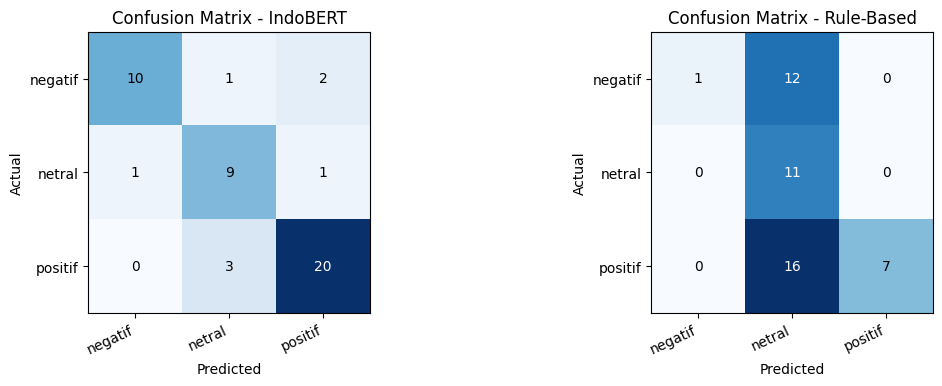

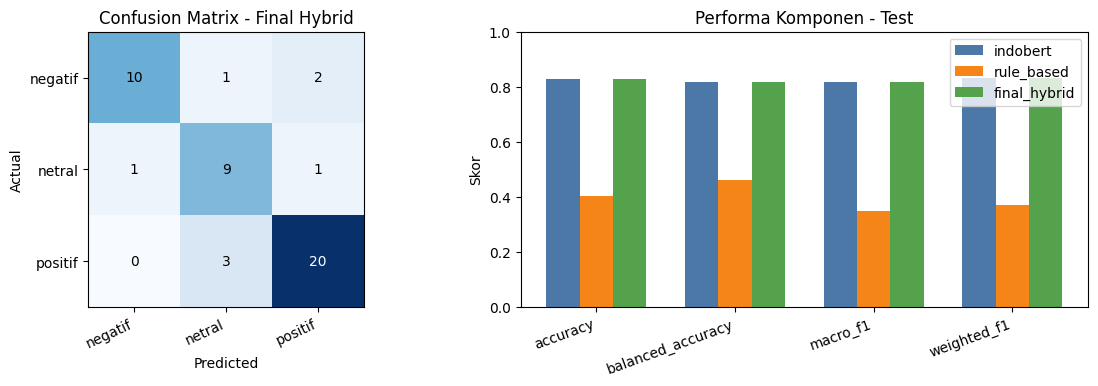

In [8]:
if metrics is None or "test_after_policy_frozen" not in metrics:
    print("metrics.json belum tersedia. Jalankan tahap calibrate-indobert lebih dulu.")
else:
    test_metrics = metrics["test_after_policy_frozen"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_confusion_matrix(
        axes[0],
        test_metrics["indobert"]["confusion_matrix"],
        "Confusion Matrix - IndoBERT",
    )
    plot_confusion_matrix(
        axes[1],
        test_metrics["rule_based"]["confusion_matrix"],
        "Confusion Matrix - Rule-Based",
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_confusion_matrix(
        axes[0],
        test_metrics["final_hybrid"]["confusion_matrix"],
        "Confusion Matrix - Final Hybrid",
    )

    metric_rows = component_metric_table(test_metrics)
    metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
    x = range(len(metric_names))
    width = 0.24
    colors = ["#4c78a8", "#f58518", "#54a24b"]
    for offset, row in enumerate(metric_rows):
        positions = [item + (offset - 1) * width for item in x]
        axes[1].bar(
            positions,
            [row[name] for name in metric_names],
            width=width,
            label=row["component"],
            color=colors[offset % len(colors)],
        )
    axes[1].set_title("Performa Komponen - Test")
    axes[1].set_xticks(list(x), metric_names, rotation=20, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Skor")
    axes[1].legend()
    fig.tight_layout(pad=1.2)
    plt.show()


## 8. Sebaran Dataset dan Output Runtime

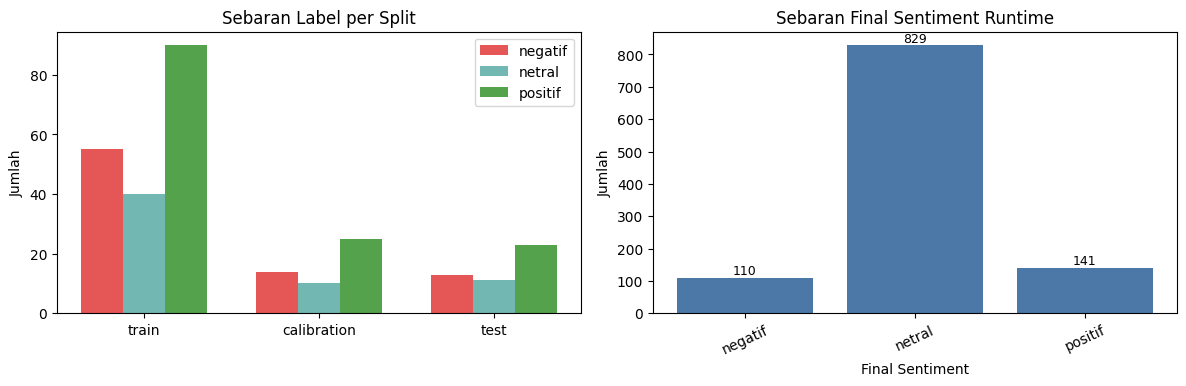

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
    split_df = pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH)
    grouped = split_df.group_by(["split", "sentiment_label"]).len().to_dicts()
    splits = ["train", "calibration", "test"]
    x = range(len(splits))
    width = 0.24
    colors = {"negatif": "#e45756", "netral": "#72b7b2", "positif": "#54a24b"}
    for offset, label in enumerate(LABEL_ORDER):
        values = [
            next(
                (
                    int(row["len"])
                    for row in grouped
                    if row["split"] == split and row["sentiment_label"] == label
                ),
                0,
            )
            for split in splits
        ]
        positions = [item + (offset - 1) * width for item in x]
        axes[0].bar(positions, values, width=width, label=label, color=colors[label])
    axes[0].set_title("Sebaran Label per Split")
    axes[0].set_xticks(list(x), splits)
    axes[0].set_ylabel("Jumlah")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Split dataset belum tersedia", ha="center", va="center")
    axes[0].set_axis_off()

if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)
    final_counts = counts_from_series(predictions_df["final_sentiment"].to_list())
    plot_count_bar(
        axes[1],
        final_counts,
        "Sebaran Final Sentiment Runtime",
        xlabel="Final Sentiment",
        order=LABEL_ORDER,
    )
else:
    axes[1].text(0.5, 0.5, "Runtime predictions belum tersedia", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout(pad=1.2)
plt.show()


## 9. Review, Fusion Action, Confidence, dan Uncertainty

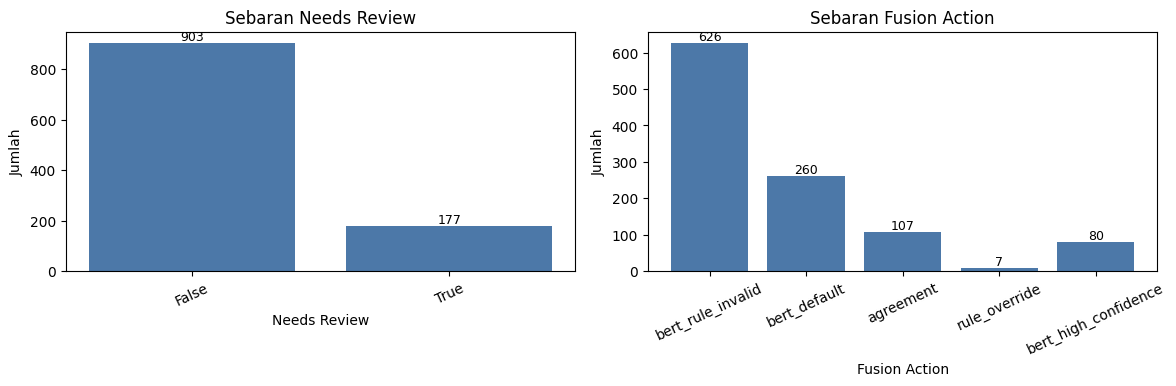

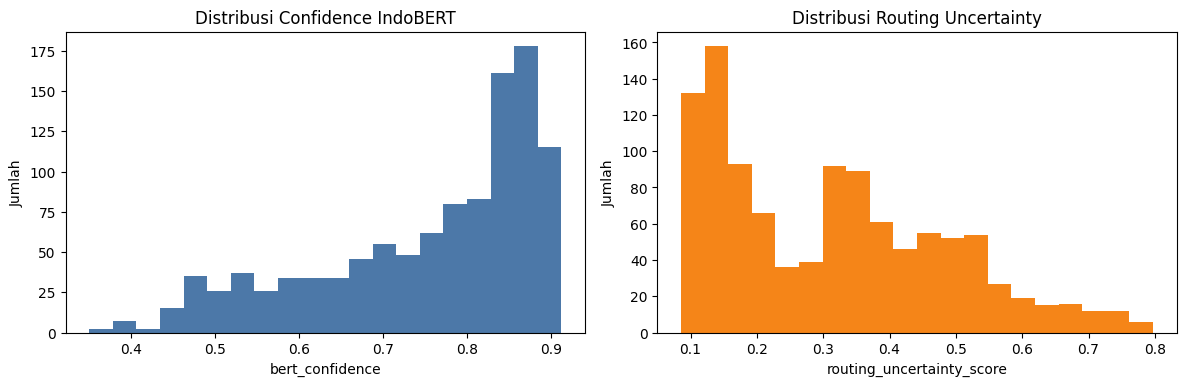

In [10]:
if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    needs_review_counts = counts_from_series(predictions_df["needs_review"].to_list())
    fusion_action_counts = counts_from_series(predictions_df["fusion_action"].to_list())
    plot_count_bar(
        axes[0],
        needs_review_counts,
        "Sebaran Needs Review",
        xlabel="Needs Review",
        order=["False", "True"],
    )
    plot_count_bar(
        axes[1],
        fusion_action_counts,
        "Sebaran Fusion Action",
        xlabel="Fusion Action",
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(predictions_df["bert_confidence"].to_list(), bins=20, color="#4c78a8")
    axes[0].set_title("Distribusi Confidence IndoBERT")
    axes[0].set_xlabel("bert_confidence")
    axes[0].set_ylabel("Jumlah")

    axes[1].hist(predictions_df["routing_uncertainty_score"].to_list(), bins=20, color="#f58518")
    axes[1].set_title("Distribusi Routing Uncertainty")
    axes[1].set_xlabel("routing_uncertainty_score")
    axes[1].set_ylabel("Jumlah")
    fig.tight_layout(pad=1.2)
    plt.show()
else:
    print("Runtime predictions belum tersedia:", predictions_path)
